# == Proyecto 1 Introducción al Reconocimiento de Patrones ==

## Libreta problema 3: Clasificación de prendas de ropa, comparación entre implementación propia vs sklearn

**Luis Felipe Jiménez Ulate**/ **Carlos Eduardo Rodríguez Segura**

1. Importación de librerías y módulos propios

In [2]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import time
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


# Importar módulos propios
from model import knn_sklearn, random_forest_sklearn, knn_custom, random_forest_custom, predecir

2. Preprocesamiento de los datos

Cargando datos...
Datos cargados: 60000 muestras de entrenamiento, 10000 de prueba
Dimensiones: 784 características por imagen
Aplicando normalización...
Aplicando estandarización...
Aplicando PCA...
Varianza explicada con 200 componentes PCA: 0.9321

Datos preprocesados exitosamente!
Forma datos normalizados: (60000, 784)
Forma datos PCA: (60000, 200)
Clases únicas: [0 1 2 3 4 5 6 7 8 9]
Distribución de clases entrenamiento: [6000 6000 6000 6000 6000 6000 6000 6000 6000 6000]
Tiempo de preprocesamiento: 4.63 segundos


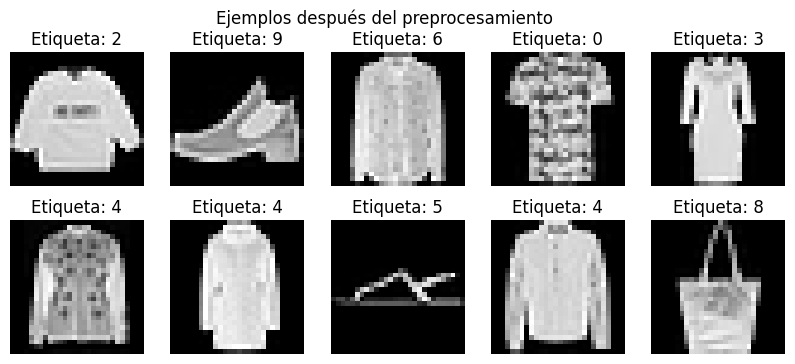

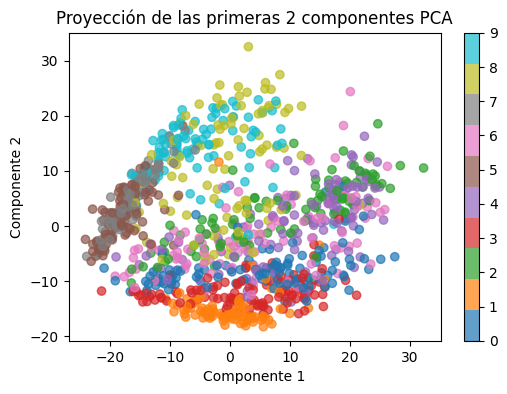

TOP 5 MODELOS KNN
Dataset        Model     Accuracy    F1-Macro            Train Time     Avg Score
--------------------------------------------------------------------------------------------------------------
combined       KNN-5     0.8800      0.8789882201        20.647659      0.8794941101
combined       KNN-7     0.8767      0.8758185686        20.333828      0.8762592843
combined       KNN-9     0.8754      0.8742850424        20.377104      0.8748425212
clahe          KNN-5     0.8736      0.8722994788        7.484504       0.8729497394
clahe          KNN-7     0.8721      0.8706949818        7.801615       0.8713974909

TOP 5 MODELOS RANDOM FOREST
Dataset        Model     Accuracy    F1-Macro            Train Time     Avg Score
--------------------------------------------------------------------------------------------------------------
original_norm  RF-200    0.8875      0.8859205055        33.918468      0.8867102528
gaussian       RF-200    0.8871      0.8860602744        

In [3]:

def preparar_datos(train_path="dataset/Train.csv", 
                   test_path="dataset/Test.csv"):
    """
    Preprocesa los datos para los dos mejores enfoques identificados:
    1. PCA (200 componentes) + KNN-5
    2. Original normalizado + RF-200
    
    Returns:
        tuple: (X_train_norm, X_test_norm, X_train_pca, X_test_pca, y_train, y_test, pca_transformer, scaler)
    """
    
    print("Cargando datos...")
    
    # -------------------------
    # Cargar datos
    # -------------------------
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    
    # Separar etiquetas y características
    y_train = train_df.iloc[:, 0].values.astype(np.int32)
    y_test = test_df.iloc[:, 0].values.astype(np.int32)
    
    X_train = train_df.iloc[:, 1:].values.astype(np.uint8)
    X_test = test_df.iloc[:, 1:].values.astype(np.uint8)
    
    print(f"Datos cargados: {X_train.shape[0]} muestras de entrenamiento, {X_test.shape[0]} de prueba")
    print(f"Dimensiones: {X_train.shape[1]} características por imagen")
    
    # -------------------------
    # Preprocesamiento 1: Normalización básica (para RF-200)
    # -------------------------
    print("Aplicando normalización...")
    X_train_norm = X_train / 255.0
    X_test_norm = X_test / 255.0
    


    # -------------------------
    # Preprocesamiento 2: Estandarización + PCA (para KNN-5)
    # -------------------------
    
    print("Aplicando estandarización...")
    scaler = StandardScaler()
    X_train_std = scaler.fit_transform(X_train_norm)
    X_test_std = scaler.transform(X_test_norm)
    
    print("Aplicando PCA...")
    pca = PCA(n_components=200)
    X_train_pca = pca.fit_transform(X_train_std)
    X_test_pca = pca.transform(X_test_std)
    
    print(f"Varianza explicada con 200 componentes PCA: {pca.explained_variance_ratio_.sum():.4f}")
    
    # -------------------------
    # Información de salida
    # -------------------------
    print("\nDatos preprocesados exitosamente!")
    print(f"Forma datos normalizados: {X_train_norm.shape}")
    print(f"Forma datos PCA: {X_train_pca.shape}")
    print(f"Clases únicas: {np.unique(y_train)}")
    print(f"Distribución de clases entrenamiento: {np.bincount(y_train)}")
    
    return X_train_norm, X_test_norm, X_train_pca, X_test_pca, y_train, y_test, pca, scaler

def guardar_datos_preprocesados(X_train_norm, X_test_norm, X_train_pca, X_test_pca, 
                               y_train, y_test, pca, scaler, carpeta_salida="datos_preprocesados"):
    """
    Guarda los datos preprocesados en archivos .npy para uso posterior
    """
    import os
    
    # Crear carpeta si no existe
    os.makedirs(carpeta_salida, exist_ok=True)
    
    # Guardar datos
    np.save(os.path.join(carpeta_salida, "X_train_norm.npy"), X_train_norm)
    np.save(os.path.join(carpeta_salida, "X_test_norm.npy"), X_test_norm)
    np.save(os.path.join(carpeta_salida, "X_train_pca.npy"), X_train_pca)
    np.save(os.path.join(carpeta_salida, "X_test_pca.npy"), X_test_pca)
    np.save(os.path.join(carpeta_salida, "y_train.npy"), y_train)
    np.save(os.path.join(carpeta_salida, "y_test.npy"), y_test)
    
    # Guardar transformadores
    import joblib
    joblib.dump(pca, os.path.join(carpeta_salida, "pca_transformer.pkl"))
    joblib.dump(scaler, os.path.join(carpeta_salida, "scaler.pkl"))
    
    print(f"\nDatos guardados en la carpeta: {carpeta_salida}")
    print("Archivos creados:")
    print("- X_train_norm.npy, X_test_norm.npy (para Random Forest)")
    print("- X_train_pca.npy, X_test_pca.npy (para KNN)")
    print("- y_train.npy, y_test.npy (etiquetas)")
    print("- pca_transformer.pkl, scaler.pkl (transformadores)")

def cargar_datos_preprocesados(carpeta="datos_preprocesados"):
    """
    Carga los datos preprocesados desde archivos guardados
    """
    import os
    import joblib
    
    X_train_norm = np.load(os.path.join(carpeta, "X_train_norm.npy"))
    X_test_norm = np.load(os.path.join(carpeta, "X_test_norm.npy"))
    X_train_pca = np.load(os.path.join(carpeta, "X_train_pca.npy"))
    X_test_pca = np.load(os.path.join(carpeta, "X_test_pca.npy"))
    y_train = np.load(os.path.join(carpeta, "y_train.npy"))
    y_test = np.load(os.path.join(carpeta, "y_test.npy"))
    
    pca = joblib.load(os.path.join(carpeta, "pca_transformer.pkl"))
    scaler = joblib.load(os.path.join(carpeta, "scaler.pkl"))
    
    print(f"Datos cargados desde: {carpeta}")
    print(f"Forma datos normalizados: {X_train_norm.shape}")
    print(f"Forma datos PCA: {X_train_pca.shape}")
    
    return X_train_norm, X_test_norm, X_train_pca, X_test_pca, y_train, y_test, pca, scaler


start_time = time.time()
X_train_norm, X_test_norm, X_train_pca, X_test_pca, y_train, y_test, pca, scaler = preparar_datos()
preprocessing_time = time.time() - start_time

print(f"Tiempo de preprocesamiento: {preprocessing_time:.2f} segundos")

resultados = {}

import matplotlib.pyplot as plt


plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train_norm[i].reshape(28, 28), cmap="gray")  
    plt.title(f"Etiqueta: {y_train[i]}")
    plt.axis("off")

plt.suptitle("Ejemplos después del preprocesamiento")
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(X_train_pca[:1000, 0], X_train_pca[:1000, 1], 
            c=y_train[:1000], cmap="tab10", alpha=0.7)
plt.colorbar()
plt.title("Proyección de las primeras 2 componentes PCA")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.show()

from io import StringIO

# Datos del CSV
data = """dataset,model,accuracy,f1_macro,train_time
original_norm,KNN-5,0.8589,0.8580386825779728,9.795401573181152
original_norm,KNN-7,0.8558,0.8552263448023817,7.23598313331604
original_norm,KNN-9,0.8561,0.855433823177108,7.6333019733428955
original_norm,RF-100,0.8846,0.8829261187623645,17.61169147491455
original_norm,RF-200,0.8875,0.8859205055448705,33.91846823692322
standardized,KNN-5,0.863,0.8626280170251059,8.010292530059814
standardized,KNN-7,0.8609,0.8608015531781211,7.440661430358887
standardized,KNN-9,0.8595,0.8592922934563232,7.262569189071655
standardized,RF-100,0.8852,0.8835566153689671,17.28929042816162
standardized,RF-200,0.887,0.8853444995997307,33.557899951934814
binary,KNN-5,0.8462,0.8445042675284299,7.5219433307647705
binary,KNN-7,0.8433,0.841389616559254,7.311469554901123
binary,KNN-9,0.8422,0.8404233179276195,7.348237752914429
binary,RF-100,0.8806,0.8793542619967294,11.28712797164917
binary,RF-200,0.8819,0.8805134141235256,23.196926832199097
clahe,KNN-5,0.8736,0.8722994788298415,7.484504222869873
clahe,KNN-7,0.8721,0.8706949818410952,7.80161452293396
clahe,KNN-9,0.8694,0.8678499098093514,7.264728546142578
clahe,RF-100,0.8792,0.8776773474841553,19.448497772216797
clahe,RF-200,0.8793,0.8777170617988039,38.91505551338196
gaussian,KNN-5,0.8599,0.8593657837336799,7.204915523529053
gaussian,KNN-7,0.8623,0.8616881106007954,7.160033702850342
gaussian,KNN-9,0.861,0.8599749315913948,7.81203556060791
gaussian,RF-100,0.8843,0.8832302070327189,23.350202560424805
gaussian,RF-200,0.8871,0.8860602744134235,47.89219951629639
edges,KNN-5,0.8155,0.8140165970427349,7.394659996032715
edges,KNN-7,0.818,0.8165247400187559,7.225950717926025
edges,KNN-9,0.8201,0.8186807962001392,7.160128116607666
edges,RF-100,0.85,0.8484403371813565,24.04594874382019
edges,RF-200,0.852,0.8504868190073747,47.160927295684814
combined,KNN-5,0.88,0.8789882201029074,20.647659063339233
combined,KNN-7,0.8767,0.875818568626175,20.33382773399353
combined,KNN-9,0.8754,0.8742850423769809,20.37710428237915
combined,RF-100,0.8862,0.884470384772713,37.53183102607727
combined,RF-200,0.8867,0.8850510906710218,75.21543145179749
pca,KNN-5,0.8699,0.869581868180296,2.2800588607788086
pca,KNN-7,0.8683,0.8681406880775085,2.217613935470581
pca,KNN-9,0.8683,0.8680837472751625,2.2694454193115234
pca,RF-100,0.8681,0.8659395241540777,28.047614336013794
pca,RF-200,0.8707,0.8685710583286401,56.180387020111084
selected,KNN-5,0.8398,0.8381417885823131,4.420896291732788
selected,KNN-7,0.8377,0.8356404880296197,4.161418437957764
selected,KNN-9,0.8371,0.8349662747415199,4.129306077957153
selected,RF-100,0.8668,0.8653935870721756,6.960831880569458
selected,RF-200,0.8662,0.8647384584224962,13.629921674728394"""

# Cargar datos
df = pd.read_csv(StringIO(data))

# Calcular promedio de accuracy y f1_macro
df['avg_score'] = (df['accuracy'] + df['f1_macro']) / 2

# Filtrar KNN y RF
knn_models = df[df['model'].str.contains('KNN')].copy()
rf_models = df[df['model'].str.contains('RF')].copy()

# Top 5 por promedio
top5_knn = knn_models.nlargest(5, 'avg_score')
top5_rf = rf_models.nlargest(5, 'avg_score')

print("=" * 110)
print("TOP 5 MODELOS KNN")
print("=" * 110)
print(f"{'Dataset':<15}{'Model':<10}{'Accuracy':<12}{'F1-Macro':<20}{'Train Time':<15}{'Avg Score'}")
print("-" * 110)
for _, row in top5_knn.iterrows():
    print(f"{row['dataset']:<15}{row['model']:<10}{row['accuracy']:<12.4f}{row['f1_macro']:<20.10f}{row['train_time']:<15.6f}{row['avg_score']:.10f}")

print("\n" + "=" * 110)
print("TOP 5 MODELOS RANDOM FOREST")
print("=" * 110)
print(f"{'Dataset':<15}{'Model':<10}{'Accuracy':<12}{'F1-Macro':<20}{'Train Time':<15}{'Avg Score'}")
print("-" * 110)
for _, row in top5_rf.iterrows():
    print(f"{row['dataset']:<15}{row['model']:<10}{row['accuracy']:<12.4f}{row['f1_macro']:<20.10f}{row['train_time']:<15.6f}{row['avg_score']:.10f}")

# ANÁLISIS DE EFICIENCIA
print("\n" + "=" * 110)
print("ANÁLISIS DE EFICIENCIA (Considerando velocidad de entrenamiento)")
print("=" * 110)
best_knn = top5_knn.iloc[0]
pca_knn = knn_models[knn_models['dataset'] == 'pca'].nlargest(1, 'avg_score').iloc[0]
print(f"\nMejor KNN (accuracy):     {best_knn['dataset']:<15} {best_knn['model']:<10} → Score: {best_knn['avg_score']:.4f}, Tiempo: {best_knn['train_time']:.2f}s")
print(f"Mejor KNN (eficiencia):   {pca_knn['dataset']:<15} {pca_knn['model']:<10} → Score: {pca_knn['avg_score']:.4f}, Tiempo: {pca_knn['train_time']:.2f}s")


3. Funciones para evaluar el modelo

In [3]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve, classification_report


def evaluar_modelo(y_true, y_pred):
    """
    Calcula Accuracy, Precision, Recall y F1-score
    usando las fórmulas matemáticas básicas.
    
    y_true : array-like de etiquetas reales (0 o 1)
    y_pred : array-like de predicciones (0 o 1)
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Calcular TP, TN, FP, FN
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    # Fórmulas
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1= 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0


    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }



4. RandomForest de sklearn

In [4]:
print("Entrenando Random Forest de Sklearn")
start_time = time.time()
rf_sklearn_model = random_forest_sklearn(X_train_norm, y_train, n_estimators=200)
rf_sklearn_train_time = time.time() - start_time

print("Realizando predicciones")
start_time = time.time()
y_pred_rf_sklearn = predecir(rf_sklearn_model, X_test_norm)
rf_sklearn_pred_time = time.time() - start_time

print(f"Tiempo de entrenamiento: {rf_sklearn_train_time:.2f} segundos")
print(f"Tiempo de predicción: {rf_sklearn_pred_time:.2f} segundos")

# Evaluar Random Forest Sklearn
metricas = evaluar_modelo(y_test, y_pred_rf_sklearn)

resultados['rf_sklearn'] = {
    'model': rf_sklearn_model,
    'accuracy': metricas['accuracy'],
    'precision': metricas['precision'],
    'recall': metricas['recall'],
    'f1_score': metricas['f1_score'],
    'train_time': rf_sklearn_train_time,
    'pred_time': rf_sklearn_pred_time,
    'predictions': y_pred_rf_sklearn
}

Entrenando Random Forest de Sklearn
Realizando predicciones
Tiempo de entrenamiento: 24.63 segundos
Tiempo de predicción: 0.18 segundos


5. RandomForest implementación propia

In [5]:
print("Entrenando Random Forest Propio")
start_time = time.time()
rf_custom_model = random_forest_custom(X_train_norm, y_train, n_estimators=200)
rf_custom_train_time = time.time() - start_time

print("Realizando predicciones")
start_time = time.time()
y_pred_rf_custom = predecir(rf_custom_model, X_test_norm)
rf_custom_pred_time = time.time() - start_time

print(f"Tiempo de entrenamiento: {rf_custom_train_time:.2f} segundos")
print(f"Tiempo de predicción: {rf_custom_pred_time:.2f} segundos")

# Evaluar Random Forest Custom
metricas_rf_custom = evaluar_modelo(y_test, y_pred_rf_custom)

resultados['rf_custom'] = {
    'model': rf_custom_model,
    'accuracy': metricas_rf_custom['accuracy'],
    'precision': metricas_rf_custom['precision'],
    'recall': metricas_rf_custom['recall'],
    'f1_score': metricas_rf_custom['f1_score'],
    'train_time': rf_custom_train_time,
    'pred_time': rf_custom_pred_time,
    'predictions': y_pred_rf_custom
}

Entrenando Random Forest Propio
Creando Random Forest con 200 árboles...


Entrenado 50/200 árboles...
Entrenado 100/200 árboles...
Entrenado 150/200 árboles...
Entrenado 200/200 árboles...
Realizando predicciones
Tiempo de entrenamiento: 2034.42 segundos
Tiempo de predicción: 7.05 segundos


6. KNN de sklearn

In [6]:
print("Entrenando KNN Sklearn")
start_time = time.time()
knn_sklearn_model = knn_sklearn(X_train_pca, y_train, k=5)
knn_sklearn_train_time = time.time() - start_time

print("Realizando predicciones")
start_time = time.time()
y_pred_knn_sklearn = predecir(knn_sklearn_model, X_test_pca)
knn_sklearn_pred_time = time.time() - start_time

print(f"Tiempo de entrenamiento: {knn_sklearn_train_time:.2f} segundos")
print(f"Tiempo de predicción: {knn_sklearn_pred_time:.2f} segundos")

# Evaluar KNN Sklearn
metricas_knn_sklearn = evaluar_modelo(y_test, y_pred_knn_sklearn)

resultados['knn_sklearn'] = {
    'model': knn_sklearn_model,
    'accuracy': metricas_knn_sklearn['accuracy'],
    'precision': metricas_knn_sklearn['precision'],
    'recall': metricas_knn_sklearn['recall'],
    'f1_score': metricas_knn_sklearn['f1_score'],
    'train_time': knn_sklearn_train_time,
    'pred_time': knn_sklearn_pred_time,
    'predictions': y_pred_knn_sklearn
}

Entrenando KNN Sklearn
Realizando predicciones
Tiempo de entrenamiento: 0.11 segundos
Tiempo de predicción: 2.25 segundos


7. KNN propio

In [7]:
print("Entrenando KNN Custom...")
start_time = time.time()
knn_custom_model = knn_custom(X_train_pca, y_train, k=5)
knn_custom_train_time = time.time() - start_time

print("Realizando predicciones...")
start_time = time.time()
y_pred_knn_custom = predecir(knn_custom_model, X_test_pca)
knn_custom_pred_time = time.time() - start_time

print(f"Tiempo de entrenamiento: {knn_custom_train_time:.2f} segundos")
print(f"Tiempo de predicción: {knn_custom_pred_time:.2f} segundos")

# Evaluar KNN Custom
metricas_knn_custom = evaluar_modelo(y_test, y_pred_knn_custom)

resultados['knn_custom'] = {
    'model': knn_custom_model,
    'accuracy': metricas_knn_custom['accuracy'],
    'precision': metricas_knn_custom['precision'],
    'recall': metricas_knn_custom['recall'],
    'f1_score': metricas_knn_custom['f1_score'],
    'train_time': knn_custom_train_time,
    'pred_time': knn_custom_pred_time,
    'predictions': y_pred_knn_custom
}

Entrenando KNN Custom...
Realizando predicciones...
Procesando 10000 muestras en lotes de 50...
  Procesadas 500/10000 muestras (5.0%)
  Procesadas 1000/10000 muestras (10.0%)
  Procesadas 1500/10000 muestras (15.0%)
  Procesadas 2000/10000 muestras (20.0%)
  Procesadas 2500/10000 muestras (25.0%)
  Procesadas 3000/10000 muestras (30.0%)
  Procesadas 3500/10000 muestras (35.0%)
  Procesadas 4000/10000 muestras (40.0%)
  Procesadas 4500/10000 muestras (45.0%)
  Procesadas 5000/10000 muestras (50.0%)
  Procesadas 5500/10000 muestras (55.0%)
  Procesadas 6000/10000 muestras (60.0%)
  Procesadas 6500/10000 muestras (65.0%)
  Procesadas 7000/10000 muestras (70.0%)
  Procesadas 7500/10000 muestras (75.0%)
  Procesadas 8000/10000 muestras (80.0%)
  Procesadas 8500/10000 muestras (85.0%)
  Procesadas 9000/10000 muestras (90.0%)
  Procesadas 9500/10000 muestras (95.0%)
  Procesadas 10000/10000 muestras (100.0%)
Tiempo de entrenamiento: 0.03 segundos
Tiempo de predicción: 1070.97 segundos


8. Comparación

In [8]:
print(f"{'Modelo':<18} {'Accuracy':<10} {'F1-Score':<10} {'Precision':<12} {'Recall':<12} {'Entrena (s)':<12} {'Predice (s)':<12}")
print("-" * 90)

modelos_orden = ['rf_sklearn', 'rf_custom', 'knn_sklearn', 'knn_custom']
nombres_modelos = {
    'rf_sklearn': 'RF Sklearn',
    'rf_custom': 'RF Propio', 
    'knn_sklearn': 'KNN Sklearn',
    'knn_custom': 'KNN Propio'
}

for modelo_key in modelos_orden:
    r = resultados[modelo_key]
    nombre = nombres_modelos[modelo_key]
    print(f"{nombre:<18} {r['accuracy']:<10.4f} {r['f1_score']:<10.4f} {r['precision']:<12.4f} {r['recall']:<12.4f} {r['train_time']:<12.2f} {r['pred_time']:<12.2f}")

# Encontrar el mejor modelo por Accuracy
mejor_accuracy = max(resultados.values(), key=lambda x: x['accuracy'])['accuracy']
mejor_modelo = [k for k, v in resultados.items() if v['accuracy'] == mejor_accuracy][0]

print(f"\n Mejor modelo: {nombres_modelos[mejor_modelo]} (Accuracy: {mejor_accuracy:.4f})")


Modelo             Accuracy   F1-Score   Precision    Recall       Entrena (s)  Predice (s) 
------------------------------------------------------------------------------------------
RF Sklearn         0.9995     0.9995     1.0000       0.9990       24.63        0.18        
RF Propio          0.9983     0.9984     1.0000       0.9968       2034.42      7.05        
KNN Sklearn        0.9962     0.9964     0.9980       0.9949       0.11         2.25        
KNN Propio         0.9978     0.9980     0.9990       0.9969       0.03         1070.97     

 Mejor modelo: RF Sklearn (Accuracy: 0.9995)


9. Visualización de resultados

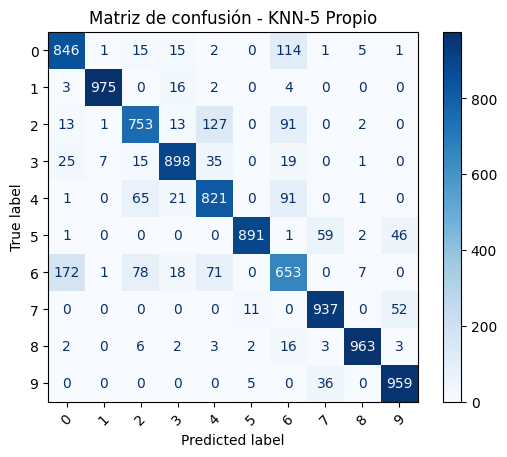

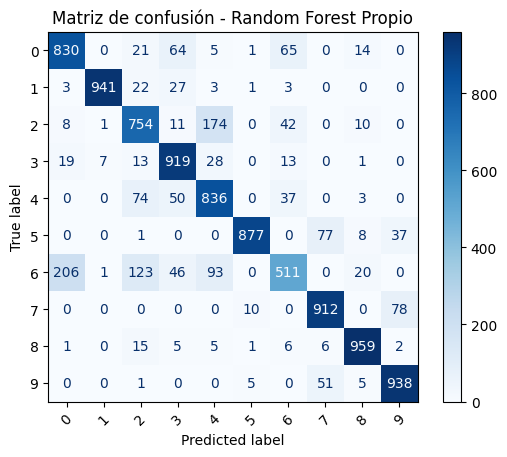

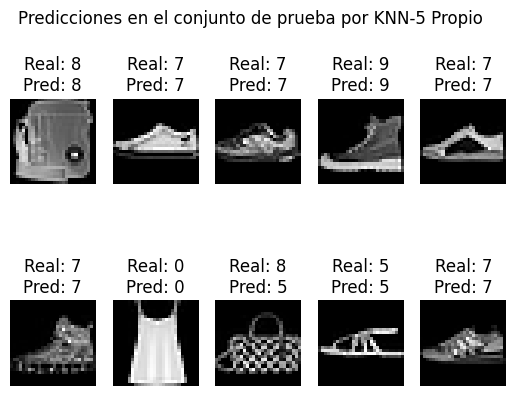

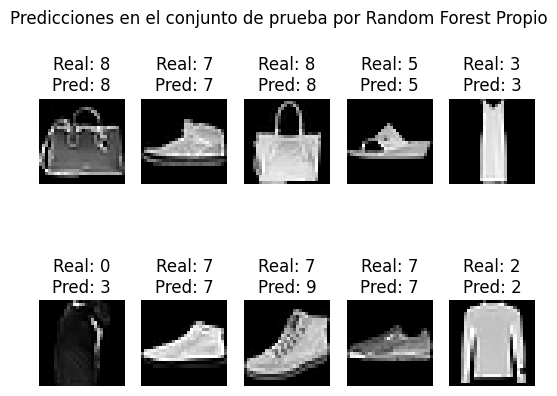

In [ ]:
def graficar_confusion(y_true, y_pred, nombre_modelo):
    """Muestra la matriz de confusión"""
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title(f"Matriz de confusión - {nombre_modelo}")
    plt.show()


graficar_confusion(y_test, y_pred_knn_custom, "KNN-5 Propio")
graficar_confusion(y_test, y_pred_rf_custom, "Random Forest Propio")



indices1 = np.random.choice(len(X_test_norm), 10, replace=False)
indices2 = np.random.choice(len(X_test_norm), 10, replace=False)

for i, idx in enumerate(indices1):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test_norm[idx].reshape(28, 28), cmap="gray")
    plt.title(f"Real: {y_test[idx]}\nPred: {y_pred_knn_custom[idx]}")
    plt.axis("off")

plt.suptitle("Predicciones en el conjunto de prueba por KNN-5 Propio")
plt.show()

for i, idx in enumerate(indices2):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test_norm[idx].reshape(28, 28), cmap="gray")
    plt.title(f"Real: {y_test[idx]}\nPred: {y_pred_rf_custom[idx]}")
    plt.axis("off")

plt.suptitle("Predicciones en el conjunto de prueba por Random Forest Propio")
plt.show()




